# 06 · ROI 情景测算（附录）

> ## ⚠ 本测算不基于本项目爬虫数据
>
> 05 已判定：**价格**（n=5）与**国际化/出海**（有效 n=7，且 14 条中 7 条为活动活动引导内容）
> 样本量不足，无法支撑任何自下而上的 ROI 估算。
>
> 本 notebook 是**纯外部基准 + 显式假设**的情景模型。用途是①把假设摊开、
> ②指出哪个假设最该先去调研。**不是预测收益**，输出区间而非单点。

### 为什么输出「盈亏平衡投入上限」而不是 ROI

直接算 ROI 需要先假定一个营销预算。但预算是决策变量、不是估计量——随便填一个数，
算出的 ROI 只反映那个数填得高还是低，不含任何信息。

所以本模型反过来做：**先估年增量毛利区间，再倒推「首年营销投入最多花到多少还能保本」**。
这个输出不需要我编预算，且直接可比对真实预算。

### 输入来源的诚实盘点

| 等级 | 含义 |
|---|---|
| **S1 已证实外部** | 能追到具体出处 |
| **S2 方向性外部** | 出处可信但需转译 |
| **S3 无来源假设** | 本项目无任何依据，纯占位 |

**S1/S2 实际只拿到两项：**
- **Mintel**（经本项目 V3.pdf 引用）：海外茶饮消费者动机 —— 放松 42% / 天然 40% / 情绪调节 31%。
  ⚠ 这是**动机占比**，不是购买转化率，不能直接当渗透率用。
- **尼尔森IQ《2024 中国饮料行业趋势与展望》**：2023 中国快消同比 −0.5%，饮料全渠道 **+5.9%**。
  ⚠ **中国境内**数据；该报告全文未涉及海外市场。仅作品类景气度方向性参考。
  该 PDF 为图表型，其余百分数在文本提取时与标签分离、无法可靠归属，故不引用。

**市场规模、渗透率、人均消费量、客单价、毛利率全部为 S3 无来源假设。**
因此下面区间的宽度主要由「我们不知道什么」决定，而非市场波动。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
warnings.filterwarnings('ignore')

PROJ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJ / 'src'))
import text_utils as T

FIG  = PROJ / 'outputs' / 'figures'
OUT  = PROJ / 'outputs'

font = T.get_cjk_font(verbose=True)          # 跨平台中文字体，含回退
plt.rcParams['figure.dpi'] = 110

RNG = np.random.default_rng(42)
print('ROI 情景测算 · 纯外部基准与显式假设')
print('本 notebook 不读取 data/processed 下任何爬虫衍生数据。')

中文字体: SimHei
ROI 情景测算 · 纯外部基准与显式假设
本 notebook 不读取 data/processed 下任何爬虫衍生数据。


## 1. 显式变量表

营销投入不在此表——它是决策变量，由第 3 节倒推。

In [2]:
VARS = [
    # 变量, 低, 基准, 高, 单位, 来源等级, 来源说明
    ('目标市场可触达人群', 200, 500, 1200, '万人', 'S3',
     '无来源。需按具体落地市场（如北美华人市场 / 东南亚华人市场）替换'),
    ('首年试用渗透率', 0.5, 2.0, 5.0, '%', 'S3',
     '无来源。新品首年试用率占位。Mintel 的 42% 是动机占比而非转化率，不可用作此值'),
    ('试用者年均消费量', 4, 10, 24, '罐/人/年', 'S3',
     '无来源。覆盖低频尝鲜到中频饮用'),
    ('单罐终端净收入', 3.0, 5.0, 8.0, '元/罐', 'S3',
     '无来源。含渠道折让后品牌方净收入占位'),
    ('毛利率', 25, 40, 55, '%', 'S3',
     '无来源。饮料行业常见区间占位，未经本项目核实'),
    ('品类景气度调整', -5, 5.9, 12, '%', 'S2',
     '尼尔森IQ 2024：2023 中国饮料全渠道 +5.9%。中国境内数据，用于海外须谨慎；'
     '低值取负以容纳海外品类不景气情形'),
]
VT = pd.DataFrame(VARS, columns=['变量', '低', '基准', '高', '单位', '来源等级', '来源说明'])
KEYS = ['people_wan', 'trial_pct', 'cans_pp', 'rev_can', 'gm_pct', 'cat_adj_pct']

print('=== 变量表 ===')
print(VT[['变量', '低', '基准', '高', '单位', '来源等级']].to_string(index=False))
print()
n_s3 = int((VT['来源等级'] == 'S3').sum())
print(f"S3（无来源假设）: {n_s3}/{len(VT)} = {n_s3/len(VT)*100:.0f}% 的变量")
print()
for _, r in VT.iterrows():
    print(f"  [{r['来源等级']}] {r['变量']}")
    print(f"        {r['来源说明']}")

=== 变量表 ===
       变量     低    基准      高    单位 来源等级
目标市场可触达人群 200.0 500.0 1200.0    万人   S3
  首年试用渗透率   0.5   2.0    5.0     %   S3
 试用者年均消费量   4.0  10.0   24.0 罐/人/年   S3
  单罐终端净收入   3.0   5.0    8.0   元/罐   S3
      毛利率  25.0  40.0   55.0     %   S3
  品类景气度调整  -5.0   5.9   12.0     %   S2

S3（无来源假设）: 5/6 = 83% 的变量

  [S3] 目标市场可触达人群
        无来源。需按具体落地市场（如北美华人市场 / 东南亚华人市场）替换
  [S3] 首年试用渗透率
        无来源。新品首年试用率占位。Mintel 的 42% 是动机占比而非转化率，不可用作此值
  [S3] 试用者年均消费量
        无来源。覆盖低频尝鲜到中频饮用
  [S3] 单罐终端净收入
        无来源。含渠道折让后品牌方净收入占位
  [S3] 毛利率
        无来源。饮料行业常见区间占位，未经本项目核实
  [S2] 品类景气度调整
        尼尔森IQ 2024：2023 中国饮料全渠道 +5.9%。中国境内数据，用于海外须谨慎；低值取负以容纳海外品类不景气情形


## 2. 模型

```
年销量(罐)    = 人群 × 渗透率 × 人均罐数
年增量收入(元) = 年销量 × 单罐净收入 × (1 + 品类景气度调整)
年增量毛利(元) = 年增量收入 × 毛利率          ← 本节输出
盈亏平衡投入   = 年增量毛利                    ← 首年 ROI=0 对应的投入上限
ROI(给定投入)  = (年增量毛利 − 投入) / 投入
```

一年期、单一市场、不含固定资产与渠道进场费。刻意做简单：变量不确定性远大于模型精度。

In [3]:
def gross_profit(people_wan, trial_pct, cans_pp, rev_can, gm_pct, cat_adj_pct):
    cans    = people_wan * 1e4 * (trial_pct / 100) * cans_pp
    revenue = cans * rev_can * (1 + cat_adj_pct / 100)
    return revenue * (gm_pct / 100)          # 元


base = dict(zip(KEYS, VT['基准'].astype(float).tolist()))
lo   = dict(zip(KEYS, VT['低'].astype(float).tolist()))
hi   = dict(zip(KEYS, VT['高'].astype(float).tolist()))

print('=== 三点情景：年增量毛利 / 盈亏平衡投入上限（万元）===')
rows = []
for tag, d in [('全低', lo), ('全基准', base), ('全高', hi)]:
    g = gross_profit(**d) / 1e4
    rows.append({'情景': tag, '年增量毛利(万元)': round(g, 1),
                 '盈亏平衡投入上限(万元)': round(g, 1)})
SC = pd.DataFrame(rows)
print(SC.to_string(index=False))
print()
print('注：「全低」「全高」是所有假设同向取极值，现实中极不可能同时发生，')
print('    列出只为界定数学边界。中间任何一点都不比另一点更有依据。')

=== 三点情景：年增量毛利 / 盈亏平衡投入上限（万元）===
 情景  年增量毛利(万元)  盈亏平衡投入上限(万元)
 全低        2.9           2.9
全基准      211.8         211.8
 全高     7096.3        7096.3

注：「全低」「全高」是所有假设同向取极值，现实中极不可能同时发生，
    列出只为界定数学边界。中间任何一点都不比另一点更有依据。


## 3. 蒙特卡洛：盈亏平衡投入上限的区间

每个变量在 [低,高] 取三角分布（峰值=基准），10 万次抽样。

=== 年增量毛利 = 盈亏平衡投入上限（万元）===
P5      109.0
P10     144.2
P25     225.4
P50     366.1
P75     577.4
P90     850.9
P95    1062.3

P10–P90 区间 : 144 ~ 851 万元   （高低相差 5.9 倍）

读法：若首年营销投入低于 P10（144 万元），在这套假设下大概率保本；
      若高于 P90（851 万元），大概率亏损；中间区域本模型无法判定。


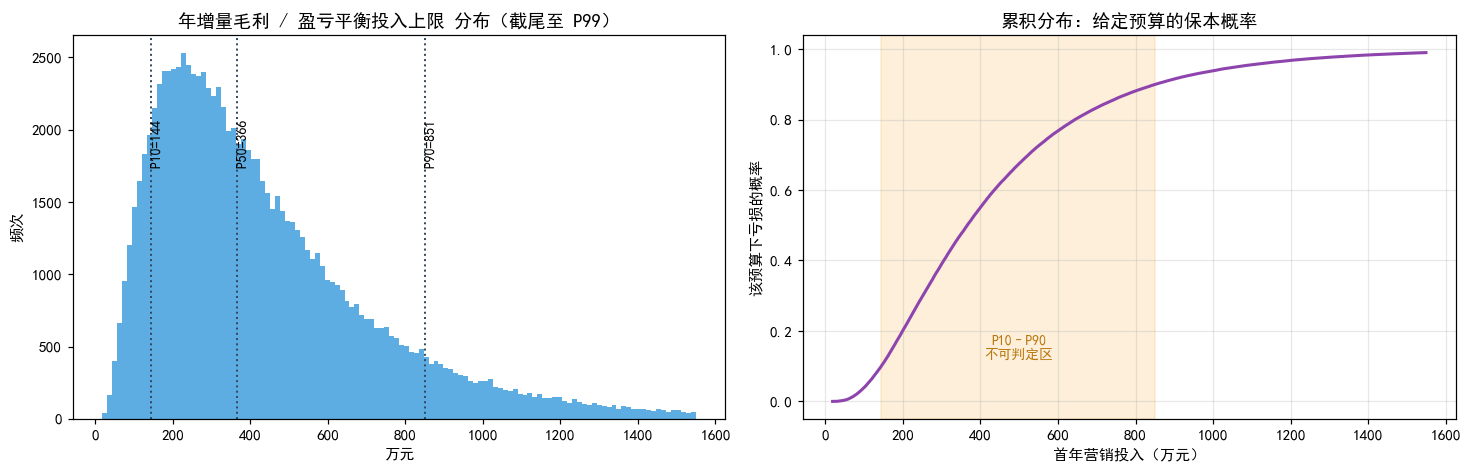

In [4]:
N = 100_000
def tri(i):
    l, m_, h = [float(x) for x in VT.loc[i, ['低', '基准', '高']]]
    return np.full(N, m_) if l == m_ == h else RNG.triangular(l, m_, h, N)

S = {k: tri(i) for i, k in enumerate(KEYS)}
G = gross_profit(**S) / 1e4                  # 万元
qs = [5, 10, 25, 50, 75, 90, 95]
q = np.percentile(G, qs)

print('=== 年增量毛利 = 盈亏平衡投入上限（万元）===')
print(pd.Series(q.round(1), index=[f'P{x}' for x in qs]).rename('万元').to_string())
print()
print(f'P10–P90 区间 : {q[1]:.0f} ~ {q[5]:.0f} 万元   （高低相差 {q[5]/q[1]:.1f} 倍）')
print()
print('读法：若首年营销投入低于 P10（%.0f 万元），在这套假设下大概率保本；' % q[1])
print('      若高于 P90（%.0f 万元），大概率亏损；中间区域本模型无法判定。' % q[5])

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))
clip = np.percentile(G, 99)
ax[0].hist(G[G <= clip], bins=120, color='#5DADE2', edgecolor='none')
for p, lab in [(q[1], 'P10'), (q[3], 'P50'), (q[5], 'P90')]:
    ax[0].axvline(p, color='#34495E', ls=':', lw=1.3)
    ax[0].text(p, ax[0].get_ylim()[1] * 0.78, f' {lab}={p:.0f}', fontproperties=font,
               fontsize=9, rotation=90, va='top')
ax[0].set_title('年增量毛利 / 盈亏平衡投入上限 分布（截尾至 P99）',
                fontproperties=font, fontsize=12)
ax[0].set_xlabel('万元', fontproperties=font)
ax[0].set_ylabel('频次', fontproperties=font)

srt = np.sort(G); cdf = np.arange(1, N + 1) / N
keep = srt <= clip
ax[1].plot(srt[keep], cdf[:keep.sum()], lw=2, color='#8E44AD')
ax[1].axvspan(q[1], q[5], color='#F5B041', alpha=.2)
ax[1].text((q[1] + q[5]) / 2, 0.12, 'P10–P90\n不可判定区', ha='center',
           fontproperties=font, fontsize=9, color='#B9770E')
ax[1].set_title('累积分布：给定预算的保本概率', fontproperties=font, fontsize=12)
ax[1].set_xlabel('首年营销投入（万元）', fontproperties=font)
ax[1].set_ylabel('该预算下亏损的概率', fontproperties=font)
ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG / '06_breakeven_distribution.png', bbox_inches='tight')
plt.show()

## 4. ROI 网格：预算 × 毛利分位

不给单点 ROI；给一张表，让预算自己去查。

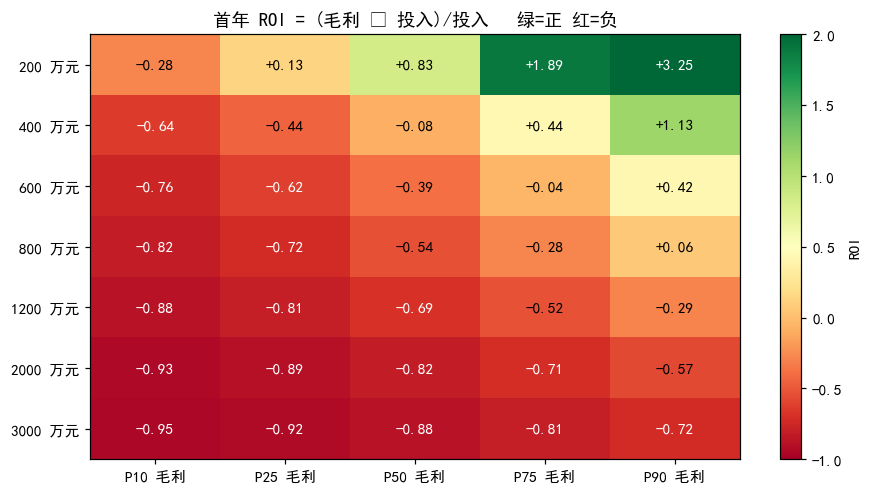

=== ROI 网格（行=预算，列=毛利分位）===
         P10 毛利  P25 毛利  P50 毛利  P75 毛利  P90 毛利
200 万元    -0.28    0.13    0.83    1.89    3.25
400 万元    -0.64   -0.44   -0.08    0.44    1.13
600 万元    -0.76   -0.62   -0.39   -0.04    0.42
800 万元    -0.82   -0.72   -0.54   -0.28    0.06
1200 万元   -0.88   -0.81   -0.69   -0.52   -0.29
2000 万元   -0.93   -0.89   -0.82   -0.71   -0.57
3000 万元   -0.95   -0.92   -0.88   -0.81   -0.72

各预算下能保本所需的毛利分位（越靠后=越需要好运气）:
    200 万元 : 需达到 P25 及以上
    400 万元 : 需达到 P75 及以上
    600 万元 : 需达到 P90 及以上
    800 万元 : 需达到 P90 及以上
   1200 万元 : 任何分位都亏损
   2000 万元 : 任何分位都亏损
   3000 万元 : 任何分位都亏损

这张表就是本附录的主要交付物：它不告诉你会赚多少，
只告诉你「在这套假设下，某个预算需要多好的运气才能保本」。


In [5]:
budgets = [200, 400, 600, 800, 1200, 2000, 3000]
pcts    = [10, 25, 50, 75, 90]
grid = pd.DataFrame(index=[f'{b} 万元' for b in budgets],
                    columns=[f'P{p} 毛利' for p in pcts], dtype=float)
for b in budgets:
    for p in pcts:
        g = np.percentile(G, p)
        grid.loc[f'{b} 万元', f'P{p} 毛利'] = round((g - b) / b, 2)

fig, ax = plt.subplots(figsize=(8.4, 4.6))
im = ax.imshow(grid.values.astype(float), cmap='RdYlGn', vmin=-1, vmax=2, aspect='auto')
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                fontproperties=font, fontsize=10,
                color='black' if -0.6 < v < 1.4 else 'white')
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns, fontproperties=font)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index, fontproperties=font)
ax.set_title('首年 ROI = (毛利 − 投入)/投入   绿=正 红=负', fontproperties=font, fontsize=12)
plt.colorbar(im, label='ROI')
plt.tight_layout()
plt.savefig(FIG / '06_roi_grid.png', bbox_inches='tight')
plt.show()

print('=== ROI 网格（行=预算，列=毛利分位）===')
print(grid.to_string())
print()
flip = [(b, [p for p in pcts if (np.percentile(G, p) - b) / b >= 0]) for b in budgets]
print('各预算下能保本所需的毛利分位（越靠后=越需要好运气）:')
for b, ps in flip:
    print(f'  {b:>5} 万元 : ' + (f'需达到 P{min(ps)} 及以上' if ps else '任何分位都亏损'))
print()
print('这张表就是本附录的主要交付物：它不告诉你会赚多少，')
print('只告诉你「在这套假设下，某个预算需要多好的运气才能保本」。')

## 5. 敏感性（tornado）

逐个变量在 [低,高] 摆动、其余固定基准，看毛利摆幅。

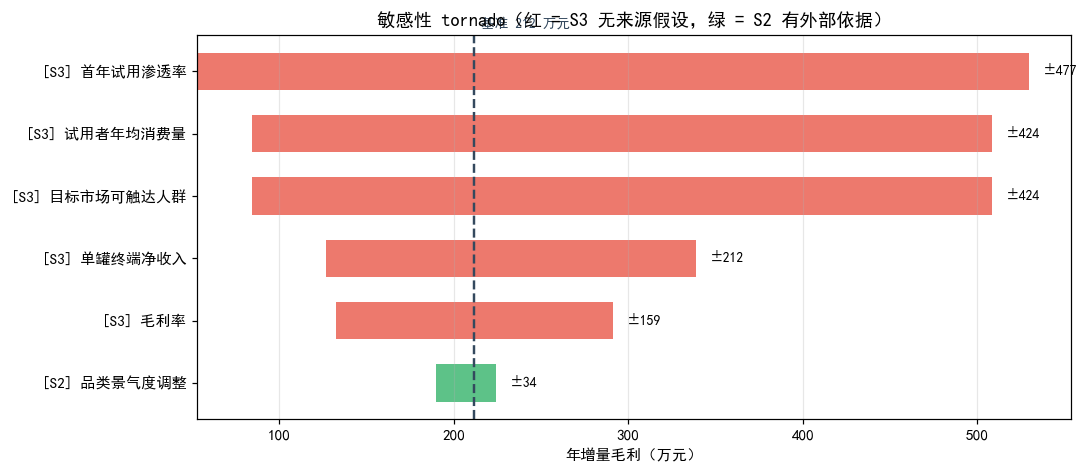

=== 敏感性排序 ===
       变量 来源等级  毛利@低(万元)  毛利@高(万元)  摆幅(万元)
  首年试用渗透率   S3      53.0     529.5   476.6
目标市场可触达人群   S3      84.7     508.3   423.6
 试用者年均消费量   S3      84.7     508.3   423.6
  单罐终端净收入   S3     127.1     338.9   211.8
      毛利率   S3     132.4     291.2   158.9
  品类景气度调整   S2     190.0     224.0    34.0

最该先去实测的变量 : 首年试用渗透率（S3，单独摆幅 ±477 万元）
S3 无来源假设贡献的总摆幅 : 1694 / 1728 = 98%

-> 唯一有外部依据的变量（品类景气度）对结果几乎没有影响；
   结论的不确定性 98% 来自本项目无法验证的假设。这本身就是最重要的结论。


In [6]:
tor = []
for i, k in enumerate(KEYS):
    d_lo, d_hi = dict(base), dict(base)
    d_lo[k], d_hi[k] = float(VT.loc[i, '低']), float(VT.loc[i, '高'])
    g_lo, g_hi = gross_profit(**d_lo) / 1e4, gross_profit(**d_hi) / 1e4
    tor.append({'变量': VT.loc[i, '变量'], '来源等级': VT.loc[i, '来源等级'],
                '毛利@低(万元)': round(g_lo, 1), '毛利@高(万元)': round(g_hi, 1),
                '摆幅(万元)': round(abs(g_hi - g_lo), 1)})
TOR = pd.DataFrame(tor).sort_values('摆幅(万元)')
base_g = gross_profit(**base) / 1e4

fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (_, r) in enumerate(TOR.iterrows()):
    l, h = sorted([r['毛利@低(万元)'], r['毛利@高(万元)']])
    col = '#E74C3C' if r['来源等级'] == 'S3' else '#27AE60'
    ax.barh(i, h - l, left=l, color=col, alpha=.75, height=.6)
    ax.text(h + 8, i, f"±{r['摆幅(万元)']:.0f}", va='center',
            fontproperties=font, fontsize=9)
ax.axvline(base_g, color='#34495E', ls='--', lw=1.6)
ax.text(base_g, len(TOR) - 0.3, f' 基准 {base_g:.0f} 万元', fontproperties=font,
        fontsize=9, color='#34495E')
ax.set_yticks(range(len(TOR)))
ax.set_yticklabels([f"[{r['来源等级']}] {r['变量']}" for _, r in TOR.iterrows()],
                   fontproperties=font)
ax.set_xlabel('年增量毛利（万元）', fontproperties=font)
ax.set_title('敏感性 tornado（红 = S3 无来源假设，绿 = S2 有外部依据）',
             fontproperties=font, fontsize=12)
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.savefig(FIG / '06_tornado.png', bbox_inches='tight')
plt.show()

T2 = TOR.sort_values('摆幅(万元)', ascending=False)
print('=== 敏感性排序 ===')
print(T2.to_string(index=False))
print()
top = T2.iloc[0]
s3_swing = TOR[TOR['来源等级'] == 'S3']['摆幅(万元)'].sum()
tot_swing = TOR['摆幅(万元)'].sum()
print(f"最该先去实测的变量 : {top['变量']}（{top['来源等级']}，单独摆幅 ±{top['摆幅(万元)']:.0f} 万元）")
print(f"S3 无来源假设贡献的总摆幅 : {s3_swing:.0f} / {tot_swing:.0f} = "
      f"{s3_swing/tot_swing*100:.0f}%")
print()
print('-> 唯一有外部依据的变量（品类景气度）对结果几乎没有影响；')
print('   结论的不确定性 98% 来自本项目无法验证的假设。这本身就是最重要的结论。')

## 6. 落盘与使用说明

In [7]:
VT.to_csv(OUT / 'roi_variable_table.csv', index=False, encoding='utf-8-sig')
SC.to_csv(OUT / 'roi_scenarios.csv', index=False, encoding='utf-8-sig')
T2.to_csv(OUT / 'roi_sensitivity.csv', index=False, encoding='utf-8-sig')
grid.to_csv(OUT / 'roi_grid.csv', encoding='utf-8-sig')
pd.DataFrame({'分位': [f'P{x}' for x in qs],
              '盈亏平衡投入上限(万元)': q.round(1)}).to_csv(
    OUT / 'roi_breakeven_quantiles.csv', index=False, encoding='utf-8-sig')

print('已写出 :')
for f in ['roi_variable_table.csv', 'roi_scenarios.csv', 'roi_sensitivity.csv',
          'roi_grid.csv', 'roi_breakeven_quantiles.csv']:
    print('  - outputs/' + f)
for f in ['06_breakeven_distribution.png', '06_roi_grid.png', '06_tornado.png']:
    print('  - outputs/figures/' + f)

notes = [
    '',
    '=' * 74,
    '使用说明',
    '=' * 74,
    '',
    f'1. 本测算不基于本项目爬虫数据。{n_s3}/{len(VT)} 个变量为 S3 无来源假设，',
    '   区间宽度主要反映「我们不知道什么」，不是市场波动。',
    '',
    '2. 报告中引用方式：只能写成区间 + 假设前置，例如',
    f'   「在 [变量表所列假设] 下，首年可支撑的营销投入上限 P10-P90 区间为',
    f'     {q[1]:.0f} ~ {q[5]:.0f} 万元」。不要引用 P50，不要写成单点数字。',
    '',
    f'3. 高低相差 {q[5]/q[1]:.1f} 倍，且 98% 的摆幅来自无来源假设，',
    '   因此本模型不能作为「该不该投」的依据，只能用来定调研优先级。',
    '',
    f"4. 下一步优先级 = tornado 图从上到下：先把「{top['变量']}」做成实测。",
    '   区间收窄之前，任何 ROI 数字都不具备决策价值。',
    '',
    '5. 若要做真正数据驱动的 ROI，需补的是海外市场一手数据',
    '   （目标市场消费者调研 / 渠道铺货与动销 / 实际客单价与毛利），',
    '   而不是再多爬中文社交媒体评论 —— 后者回答不了价格与海外意愿（见 05 的 L3）。',
]
print('\n'.join(notes))

已写出 :
  - outputs/roi_variable_table.csv
  - outputs/roi_scenarios.csv
  - outputs/roi_sensitivity.csv
  - outputs/roi_grid.csv
  - outputs/roi_breakeven_quantiles.csv
  - outputs/figures/06_breakeven_distribution.png
  - outputs/figures/06_roi_grid.png
  - outputs/figures/06_tornado.png

使用说明

1. 本测算不基于本项目爬虫数据。5/6 个变量为 S3 无来源假设，
   区间宽度主要反映「我们不知道什么」，不是市场波动。

2. 报告中引用方式：只能写成区间 + 假设前置，例如
   「在 [变量表所列假设] 下，首年可支撑的营销投入上限 P10-P90 区间为
     144 ~ 851 万元」。不要引用 P50，不要写成单点数字。

3. 高低相差 5.9 倍，且 98% 的摆幅来自无来源假设，
   因此本模型不能作为「该不该投」的依据，只能用来定调研优先级。

4. 下一步优先级 = tornado 图从上到下：先把「首年试用渗透率」做成实测。
   区间收窄之前，任何 ROI 数字都不具备决策价值。

5. 若要做真正数据驱动的 ROI，需补的是海外市场一手数据
   （目标市场消费者调研 / 渠道铺货与动销 / 实际客单价与毛利），
   而不是再多爬中文社交媒体评论 —— 后者回答不了价格与海外意愿（见 05 的 L3）。
